# Домашняя работа №6


Выполнил: Шалыгин Н.А.


Группа: ФПэ-01-22

----------------------------------------------------------------------------------------------------------------

Отрисовать рабочую лопатку регулирующей ступени из курсового проекта в 3D при помощи matplotlib

# Построение самого профиля 

In [1]:

%reload_ext autoreload
%autoreload 2

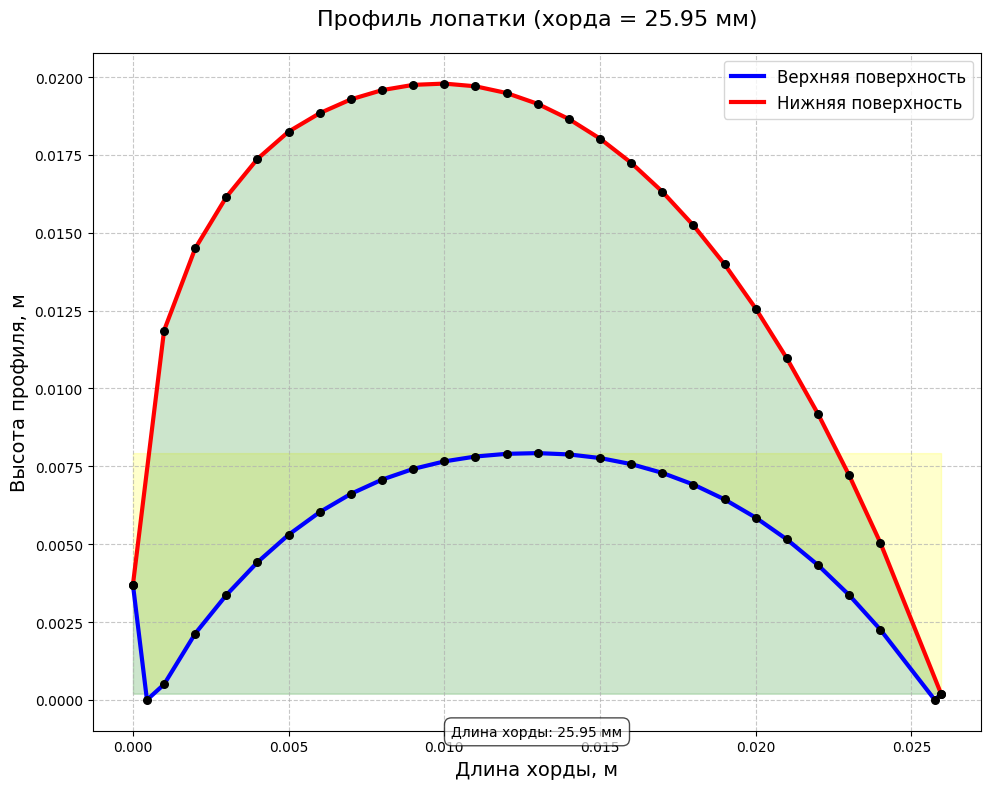

Масштабирующий коэффициент: 1.0000
Проверка длины хорды: 0.02595 м


In [31]:
import numpy as np
import matplotlib.pyplot as plt

xu_raw = np.array([0,0.45,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.75,25.95])/1000
xl_raw = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.95])/1000
yu_raw = np.array([3.7,0.0,0.5,2.13,3.368,4.422,5.305,6.032,6.617,7.074,7.417,7.659,7.816,7.902,7.925,7.883,7.767,7.572,7.29,6.915,6.438,5.853,5.153,4.328,3.366,2.259,0,0.2])/1000
yl_raw = np.array([3.7,11.862,14.5,16.15,17.375,18.25,18.842,19.285,19.581,19.75,19.791,19.704,19.488,19.139,18.652,18.023,17.247,16.32,15.235,13.986,12.565,10.966,9.182,7.209,5.049,0.2])/1000

b_lop = 0.02595 

scale_factor = b_lop / max(max(xu_raw), max(xl_raw))
xu = xu_raw * scale_factor
xl = xl_raw * scale_factor
yu = yu_raw * scale_factor
yl = yl_raw * scale_factor

fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(xu, yu, 'b-', linewidth=3, label='Верхняя поверхность')
ax.fill_between(xu, yu, max(yu), color='yellow', alpha=0.2)

ax.plot(xl, yl, 'r-', linewidth=3, label='Нижняя поверхность')
ax.fill_between(xl, yl, min(yl), color='green', alpha=0.2)

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_title(f'Профиль лопатки (хорда = {b_lop*1000:.2f} мм)', fontsize=16, pad=20)
ax.set_xlabel('Длина хорды, м', fontsize=14)
ax.set_ylabel('Высота профиля, м', fontsize=14)
ax.legend(fontsize=12, loc='upper right')

ax.scatter(xu, yu, color='black', s=30, zorder=3)
ax.scatter(xl, yl, color='black', s=30, zorder=3)

ax.annotate(f'Длина хорды: {b_lop*1000:.2f} мм', 
            xy=(b_lop/2, min(yl)-0.001),
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()

print(f"Масштабирующий коэффициент: {scale_factor:.4f}")
print(f"Проверка длины хорды: {max(max(xu), max(xl)):.5f} м")

# Трёхмерная отрисовка

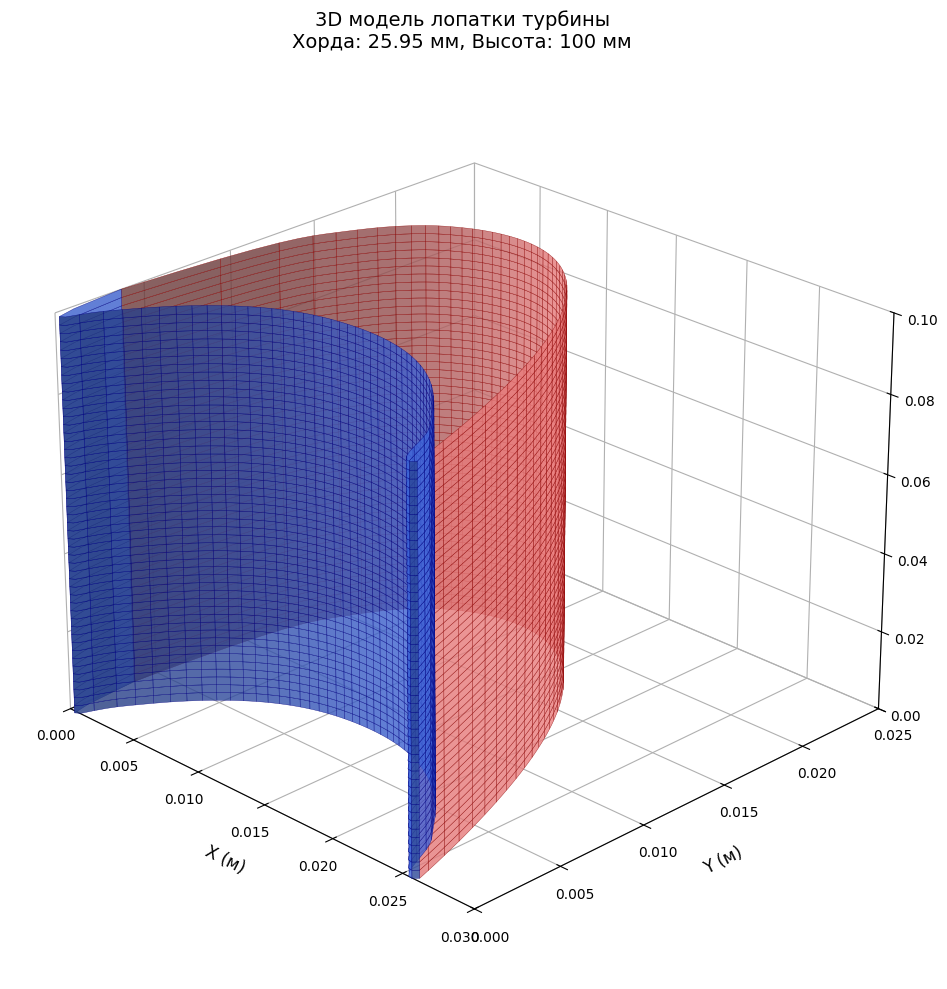

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d

xu_raw = np.array([0,0.45,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.75,25.95])/1000
xl_raw = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.95])/1000
yu_raw = np.array([3.7,0.0,0.5,2.13,3.368,4.422,5.305,6.032,6.617,7.074,7.417,7.659,7.816,7.902,7.925,7.883,7.767,7.572,7.29,6.915,6.438,5.853,5.153,4.328,3.366,2.259,0,0.2])/1000
yl_raw = np.array([3.7,11.862,14.5,16.15,17.375,18.25,18.842,19.285,19.581,19.75,19.791,19.704,19.488,19.139,18.652,18.023,17.247,16.32,15.235,13.986,12.565,10.966,9.182,7.209,5.049,0.2])/1000

b_lop = 0.02595

scale_factor = b_lop / max(max(xu_raw), max(xl_raw))
xu = xu_raw * scale_factor
xl = xl_raw * scale_factor
yu = yu_raw * scale_factor
yl = yl_raw * scale_factor

blade_length = 0.1
num_slices = 50  

f_upper = interp1d(xu, yu, kind='cubic', fill_value="extrapolate")
f_lower = interp1d(xl, yl, kind='cubic', fill_value="extrapolate")

x_fine = np.linspace(min(min(xu), min(xl)), max(max(xu), max(xl)), 100)
yu_fine = f_upper(x_fine)
yl_fine = f_lower(x_fine)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

z_levels = np.linspace(0, blade_length, num_slices)

X_upper, Z_upper = np.meshgrid(x_fine, z_levels)
Y_upper = np.array([yu_fine] * num_slices)
ax.plot_surface(X_upper, Y_upper, Z_upper, color='royalblue', alpha=0.8, edgecolor='navy', linewidth=0.3)

X_lower, Z_lower = np.meshgrid(x_fine, z_levels)
Y_lower = np.array([yl_fine] * num_slices)
ax.plot_surface(X_lower, Y_lower, Z_lower, color='lightcoral', alpha=0.8, edgecolor='darkred', linewidth=0.3)

x_front = np.array([xu[0], xl[0]])
y_front = np.array([yu[0], yl[0]])
X_front, Z_front = np.meshgrid(x_front, z_levels)
Y_front = np.array([y_front] * num_slices)
ax.plot_surface(X_front, Y_front, Z_front, color='limegreen', alpha=0.7)

x_rear = np.array([xu[-1], xl[-1]])
y_rear = np.array([yu[-1], yl[-1]])
X_rear, Z_rear = np.meshgrid(x_rear, z_levels)
Y_rear = np.array([y_rear] * num_slices)
ax.plot_surface(X_rear, Y_rear, Z_rear, color='limegreen', alpha=0.7)

ax.set_xlabel('X (м)', fontsize=12, labelpad=10)
ax.set_ylabel('Y (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Z (м)', fontsize=12, labelpad=10)
ax.set_title(f'3D модель лопатки турбины\nХорда: {25.95} мм, Высота: {100} мм', 
             fontsize=14, pad=20)

ax.view_init(elev=25, azim=-45) 

def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    
    plot_radius = 0.5*max([x_range, y_range, z_range])
    
    ax.set_xlim3d([0, 0.03])
    ax.set_ylim3d([0, 0.025])
    ax.set_zlim3d([0, blade_length])

set_axes_equal(ax)

# Добавляем сетку и улучшаем общее оформление
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

plt.tight_layout()
plt.show()

In [41]:
xu_raw = np.array([0,0.45,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.75,25.95])/1000
xl_raw = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.95])/1000
yu_raw = np.array([3.7,0.0,0.5,2.13,3.368,4.422,5.305,6.032,6.617,7.074,7.417,7.659,7.816,7.902,7.925,7.883,7.767,7.572,7.29,6.915,6.438,5.853,5.153,4.328,3.366,2.259,0,0.2])/1000
yl_raw = np.array([3.7,11.862,14.5,16.15,17.375,18.25,18.842,19.285,19.581,19.75,19.791,19.704,19.488,19.139,18.652,18.023,17.247,16.32,15.235,13.986,12.565,10.966,9.182,7.209,5.049,0.2])/1000

upper_3d = np.column_stack((
    xu, 
    yu, 
    np.full(len(xu), 0.1) 
))


lower_3d = np.column_stack((
    xl, 
    yl, 
    np.full(len(xl), 0.1) 
))

# Объединение в общий 3D массив
combined_3d = np.vstack((upper_3d, lower_3d))

In [42]:
avg_d = 0.975    
l = 0.1      
u = 188.033
density = 7800
z = 104
n = 50
W = 0.39 * 1e-6
MPa = 10e6

max_stress = 400 * MPa
max_allowed_stress = 235 * MPa

tension_stress_root_func = lambda x: 0.5 * density * (x ** 2) * avg_d * l


angular_speed = 2 * np.pi * n
assert tension_stress_root_func(angular_speed) < max_allowed_stress
print(f"Запас прочности: {max_stress / tension_stress_root_func(angular_speed)}")
increased_angular_speed = 1.1 * angular_speed
assert tension_stress_root_func(increased_angular_speed) < max_allowed_stress
tension_stress_root_func(increased_angular_speed) / MPa
print(f"Запас прочности: {max_stress / tension_stress_root_func(increased_angular_speed)}")

def tension_stress(x):
    r_root = (avg_d - l) / 2
    constant_part = density * (angular_speed ** 2)
    left = r_root * (l - x)
    right = 0.5 * ((l ** 2) - (x ** 2))
    return constant_part * (left + right)

y = np.linspace(0, l, 100)

Запас прочности: 106.58375662573336
Запас прочности: 88.08574927746558


In [43]:
import numpy as np
import matplotlib.pyplot as plt

from functools import partial
from typing import Callable, List, Tuple, Union, Optional

from scipy.integrate import dblquad, quad


def __patch_variable(value: Union[Callable, int, float]) -> Callable:
    """
    Patch variable which should be Callable. Usually it is variable depending on cross-section
    :param Union[Callable, int, float] value:
    :return Callable:
    """
    if callable(value):
        return value
    else:
        return lambda x: value
    
def __patch_multiple(*args) -> List[Callable]:
    """
    Patch multiple variables at time
    :param args: None keyword args
    :return List[Callable]:
    """
    return [__patch_variable(variable) for variable in args]


def _distribution_loading_x(
    z: Union[int, float],
    density: Callable,
    outlet_axial_speed: Callable,
    inlet_tangential_speed: Callable,
    outlet_tangential_speed: Callable,
    pitch: Callable,
) -> float:
    """
    Distribution loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_tangential_speed: Inlet tangential speed, m / s
    :param Callable outlet_tangential_speed: Outlet tangential speed, m / s
    :param Callable pitch: Blade to blade distance at cross-section z
    :return float:
    """
    rho = density(z)
    step = pitch(z)
    outlet_axial_speed_projection = outlet_axial_speed(z)
    inlet_tangential_projection = inlet_tangential_speed(z)
    outlet_tangential_projection = outlet_tangential_speed(z)
    return rho * step * outlet_axial_speed_projection * (inlet_tangential_projection + outlet_tangential_projection)


def _distribution_loading_y(
    z: Union[int, float],
    density: Callable,
    inlet_axial_speed: Callable,
    outlet_axial_speed: Callable,
    inlet_pressure_profile: Callable,
    outlet_pressure_profile: Callable,
    pitch: Callable,
) -> float:
    """
    Distribution loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_pressure_profile: Pressure before blade row, Pa
    :param Callable outlet_pressure_profile: Pressure after blade row, Pa
    :param Callable pitch: Blade to blade distance at cross-section z
    :return float:
    """
    rho = density(z)
    step = pitch(z)
    inlet_axial_projection = inlet_axial_speed(z)
    outlet_axial_projection = outlet_axial_speed(z)
    p_in = inlet_pressure_profile(z)
    p_out = outlet_pressure_profile(z)

    speed_part = rho * step * outlet_axial_projection * (inlet_axial_projection - outlet_axial_projection)
    pressure_part = step * (p_in - p_out)

    return speed_part + pressure_part


def _bending_moment_from_distributed_force(
    z: Union[int, float],
    loading: Callable,
    blade_length: Union[int, float],
) -> float:
    """
    Bending loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable loading: Loading function f(x), probably should be partial
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :return float:
    """

    def to_integrate(variable):
        return loading(variable) * (variable - z)

    moment = quad(to_integrate, z, blade_length)[0]
    return moment


def _bending_moment_projections(
    z: Union[int, float],
    blade_length: Union[int, float],
    density: Callable,
    inlet_axial_speed: Callable,
    outlet_axial_speed: Callable,
    inlet_tangential_speed: Callable,
    outlet_tangential_speed: Callable,
    inlet_pressure_profile: Callable,
    outlet_pressure_profile: Callable,
    pitch: Callable,
    angle_of_frame: Callable,
    is_rotor: bool = True,
) -> Tuple[float, float]:
    """
    Define min and max bending moments related to axis with min and max inertia moments
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_tangential_speed: Inlet tangential speed, m / s
    :param Callable outlet_tangential_speed: Outlet tangential speed, m / s
    :param Callable inlet_pressure_profile: Pressure before blade row, Pa
    :param Callable outlet_pressure_profile: Pressure after blade row, Pa
    :param Callable pitch: Blade to blade distance at cross-section z
    :param Callable angle_of_frame: Blade profile angle of frame for min-max inertia moments
    :param bool is_rotor: Binary flag to specify type of blade
    :return Tuple[float, float]: moment eta, moment zeta
    """

    angle_of_frame = __patch_variable(angle_of_frame)
    cos_beta = np.cos(np.deg2rad(angle_of_frame(z)))
    sin_beta = np.sin(np.deg2rad(angle_of_frame(z)))

    loading_x = partial(
        _distribution_loading_y,
        density=density,
        inlet_axial_speed=inlet_axial_speed,
        outlet_axial_speed=outlet_axial_speed,
        inlet_pressure_profile=inlet_pressure_profile,
        outlet_pressure_profile=outlet_pressure_profile,
        pitch=pitch,
    )

    loading_y = partial(
        _distribution_loading_x,
        density=density,
        outlet_axial_speed=outlet_axial_speed,
        inlet_tangential_speed=inlet_tangential_speed,
        outlet_tangential_speed=outlet_tangential_speed,
        pitch=pitch,
    )

    moment_x = _bending_moment_from_distributed_force(
        z=z,
        blade_length=blade_length,
        loading=loading_x,
    )
    moment_y = _bending_moment_from_distributed_force(
        z=z,
        blade_length=blade_length,
        loading=loading_y,
    )

    moment_eta = moment_y * cos_beta + moment_x * sin_beta
    moment_zeta = moment_y * sin_beta - moment_x * cos_beta

    return moment_eta, moment_zeta


def blade_bending_stress(
    z: Union[int, float],
    blade_length: Union[int, float],
    density: Union[Callable, float],
    inlet_axial_speed: Union[Callable, float],
    outlet_axial_speed: Union[Callable, float],
    inlet_tangential_speed: Union[Callable, float],
    outlet_tangential_speed: Union[Callable, float],
    inlet_pressure_profile: Union[Callable, float],
    outlet_pressure_profile: Union[Callable, float],
    pitch: Union[Callable, float],
    angle_of_frame: Union[Callable, float],
    eta_moment_inertia: Union[Callable, float],
    zeta_moment_inertia: Union[Callable, float],
    coordinates: Union[Tuple[float, float], np.ndarray],
    is_rotor: bool = True,
) -> Union[np.ndarray, float]:
    """
    Define stress from bending moment at specific cross-section Z and coordinates of profile
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :param Union[Callable, float] density: Density after blade row, kg / m ** 3
    :param Union[Callable, float] inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Union[Callable, float] outlet_axial_speed: Axial speed behind blade row, m / s
    :param Union[Callable, float] inlet_tangential_speed: Inlet tangential speed, m / s
    :param Union[Callable, float] outlet_tangential_speed: Outlet tangential speed, m / s
    :param Union[Callable, float] inlet_pressure_profile: Pressure before blade row, Pa
    :param Union[Callable, float] outlet_pressure_profile: Pressure after blade row, Pa
    :param Union[Callable, float] pitch: Blade to blade distance at cross-section z
    :param Union[Callable, float] angle_of_frame: Blade profile angle of frame for min-max inertia moments
    :param Union[Callable, float] zeta_moment_inertia: Max moment of inertia, m ** 4
    :param Union[Callable, float] eta_moment_inertia: Min moment of inertia, m ** 4
    :param Union[Tuple[float, float], np.ndarray] coordinates: Coordinates of profile to compute stress at this point.
        First coordinate related axis with min moment if inertia, second with max one. (eta_coordinate, zeta_coordinate)
    :param bool is_rotor: Binary flag to specify type of blade
    :return Union[float, np.ndarray]:
    """

    (
        density,
        inlet_axial_speed,
        outlet_axial_speed,
        inlet_tangential_speed,
        outlet_tangential_speed,
        inlet_pressure_profile,
        outlet_pressure_profile,
        pitch,
        zeta_moment_inertia,
        eta_moment_inertia,
        angle_of_frame,
    ) = __patch_multiple(
        density,
        inlet_axial_speed,
        outlet_axial_speed,
        inlet_tangential_speed,
        outlet_tangential_speed,
        inlet_pressure_profile,
        outlet_pressure_profile,
        pitch,
        zeta_moment_inertia,
        eta_moment_inertia,
        angle_of_frame,
    )

    moment_eta, moment_zeta = _bending_moment_projections(
        z=z,
        blade_length=blade_length,
        density=density,
        inlet_axial_speed=inlet_axial_speed,
        outlet_axial_speed=outlet_axial_speed,
        inlet_tangential_speed=inlet_tangential_speed,
        outlet_tangential_speed=outlet_tangential_speed,
        inlet_pressure_profile=inlet_pressure_profile,
        outlet_pressure_profile=outlet_pressure_profile,
        pitch=pitch,
        angle_of_frame=angle_of_frame,
        is_rotor=is_rotor,
    )
    if isinstance(coordinates, np.ndarray):
        if coordinates.ndim == 2:
            stress = (-moment_eta * coordinates[:, 1] / eta_moment_inertia(z)) + (
                moment_zeta * coordinates[:, 0] / zeta_moment_inertia(z)
            )
            return stress

    stress = (-moment_eta * coordinates[1] / eta_moment_inertia(z)) + (
        moment_zeta * coordinates[0] / zeta_moment_inertia(z)
    )

    return stress
def rotate(x: np.ndarray, angle: float) -> np.ndarray:
    """
    Rotate x around [0, 0] on `angle` degree
    :param np.ndarray x: [[x1, x2, x3,...], [y1, y2, y3, ...]]
    :param float angle: Angle in degree to rotate
    :return np.ndarray:
    """
    _angle = np.deg2rad(angle)
    rotation_matrix = np.array([[np.cos(_angle), -np.sin(_angle)], [np.sin(_angle), np.cos(_angle)]])

    return x.dot(rotation_matrix)

def bending_stress_coordinates(full_points, angle_of_frame, diameter) -> np.ndarray:
    """
    Full coordinates of profile to compute bending blade stress
    :return np.ndarray: np.ndarray([eta, zeta. Z])
    """
    coordinates = rotate(full_points[:, [0, 1]], 90 + angle_of_frame)
    coordinates[:, [0, 1]] = coordinates[:, [1, 0]]
    diameter = np.ones_like(coordinates[:, 0])[:, None] * diameter
    coordinates = np.hstack((coordinates, diameter))
    return coordinates

full_points = combined_3d
coordinates = bending_stress_coordinates(full_points=combined_3d, angle_of_frame=33.2, diameter=1.2)
coordinates.shape

(54, 3)

In [44]:
P_in = 26 * 1e6
P_out = 3.5 * 1e6

inlet_axial_speed=219.657679547258
outlet_axial_speed=75.69174834033075
inlet_tangential_speed=370.0835015978625
outlet_tangential_speed=12.312564410331605
eta_moment_inertia = i_minimum = 0.43
zeta_moment_inertia = i_maximum = 1.01
angle_of_frame = 77.8
angle_of_frame = angle_of_frame + 90
density = 7900
blade_length = 0.02529

bending_stress = blade_bending_stress(
    z=0.05,
    blade_length=blade_length,
    density=density,
    inlet_axial_speed=inlet_axial_speed,
    outlet_axial_speed=outlet_axial_speed,
    inlet_tangential_speed=inlet_tangential_speed,
    outlet_tangential_speed=outlet_tangential_speed,
    inlet_pressure_profile=P_in,
    outlet_pressure_profile=P_out,
    pitch=0.65,
    angle_of_frame=angle_of_frame,
    eta_moment_inertia=eta_moment_inertia,
    zeta_moment_inertia=zeta_moment_inertia,
    coordinates=coordinates,
) / 1e6

In [45]:
import numpy as np
from scipy.interpolate import interp1d
import plotly.graph_objects as go

def plot_3d_blade_with_stress(xu, yu, xl, yl, stress_distribution, 
                             height=0.1, num_points=100):

    f_u = interp1d(xu, yu, kind='cubic')
    x_u = np.linspace(min(xu), max(xu), num_points)
    y_u = f_u(x_u)
    
    f_l = interp1d(xl, yl, kind='cubic')
    x_l = np.linspace(min(xl), max(xl), num_points)
    y_l = f_l(x_l)

    z_coords = np.linspace(0, height, num_points)
    
    stress_interp = interp1d(np.linspace(0, height, len(stress_distribution)),
                            stress_distribution,
                            kind='linear',
                            fill_value='extrapolate')

    X_u, Z_u = np.meshgrid(x_u, z_coords)
    Y_u = np.array([y_u]*num_points)
    
    X_l, Z_l = np.meshgrid(x_l, z_coords)
    Y_l = np.array([y_l]*num_points)

    stress = stress_interp(z_coords)[:, np.newaxis]

    fig = go.Figure()

    fig.add_trace(go.Surface(
        x=X_u,
        y=Y_u,
        z=Z_u,
        surfacecolor=np.repeat(stress, len(x_u), axis=1),
        colorscale='Plasma',
        opacity=0.8,
        showscale=True,
        name='Напряжения',
        colorbar=dict(title='Напряжение, МПа')
    ))

    fig.add_trace(go.Surface(
        x=X_l,
        y=Y_l,
        z=Z_l,
        surfacecolor=np.repeat(stress, len(x_l), axis=1),
        colorscale='Plasma',
        showscale=False
    ))

    for i in [0, -1]: 
        fig.add_trace(go.Surface(
            x=np.array([[xu[i], xl[i]]]*num_points),
            y=np.array([[yu[i], yl[i]]]*num_points),
            z=np.array([z_coords, z_coords]).T,
            surfacecolor=stress,
            colorscale='Plasma',
            showscale=False
        ))

    fig.update_layout(
        title='Напряжений расчтяжения лопатки',
        scene=dict(
            xaxis_title='X (м)',
            yaxis_title='Y (м)',
            zaxis_title='Z (м)',
            aspectmode='manual',
            aspectratio=dict(x=2, y=1, z=0.5),
            camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
        ),
        margin=dict(l=0, r=50, b=0, t=30)
    )
    
    fig.show()


xu_raw = np.array([0,0.45,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.75,25.95])/1000
xl_raw = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.95])/1000
yu_raw = np.array([3.7,0.0,0.5,2.13,3.368,4.422,5.305,6.032,6.617,7.074,7.417,7.659,7.816,7.902,7.925,7.883,7.767,7.572,7.29,6.915,6.438,5.853,5.153,4.328,3.366,2.259,0,0.2])/1000
yl_raw = np.array([3.7,11.862,14.5,16.15,17.375,18.25,18.842,19.285,19.581,19.75,19.791,19.704,19.488,19.139,18.652,18.023,17.247,16.32,15.235,13.986,12.565,10.966,9.182,7.209,5.049,0.2])/1000

stress_values =tension_stress(y)/MPa# np.linspace(50, 100, len(xu))


plot_3d_blade_with_stress(xu, yu, xl, yl, 
                         stress_distribution=stress_values,
                         height=0.1,
                         num_points=100)

In [ ]:
import numpy as np
from scipy.interpolate import interp1d
import plotly.graph_objects as go

def plot_3d_bending_stress(xu, yu, xl, yl, 
                          blade_length, density,
                          inlet_axial_speed, outlet_axial_speed,
                          inlet_tangential_speed, outlet_tangential_speed,
                          inlet_pressure_profile, outlet_pressure_profile,
                          pitch, angle_of_frame,
                          eta_moment_inertia, zeta_moment_inertia,
                          height=0.1, num_points=100):

    f_u = interp1d(xu, yu, kind='cubic')
    x_u = np.linspace(min(xu), max(xu), num_points)
    y_u = f_u(x_u)
    
    f_l = interp1d(xl, yl, kind='cubic')
    x_l = np.linspace(min(xl), max(xl), num_points)
    y_l = f_l(x_l)

    z_levels = np.linspace(0, height, num_points)
    X_u, Z_u = np.meshgrid(x_u, z_levels)
    Y_u = np.array([y_u]*num_points)
    
    X_l, Z_l = np.meshgrid(x_l, z_levels)
    Y_l = np.array([y_l]*num_points)

    stress_upper = np.zeros_like(X_u)
    stress_lower = np.zeros_like(X_l)

    for i, z in enumerate(z_levels):
        coords_upper = np.column_stack([x_u, y_u, np.full_like(x_u, z)])
        coords_lower = np.column_stack([x_l, y_l, np.full_like(x_l, z)])

        all_coords = np.vstack([coords_upper, coords_lower])

        stresses = blade_bending_stress(
            z=z,
            blade_length=blade_length,
            density=density,
            inlet_axial_speed=inlet_axial_speed,
            outlet_axial_speed=outlet_axial_speed,
            inlet_tangential_speed=inlet_tangential_speed,
            outlet_tangential_speed=outlet_tangential_speed,
            inlet_pressure_profile=inlet_pressure_profile,
            outlet_pressure_profile=outlet_pressure_profile,
            pitch=pitch,
            angle_of_frame=angle_of_frame,
            eta_moment_inertia=eta_moment_inertia,
            zeta_moment_inertia=zeta_moment_inertia,
            coordinates=all_coords
        ) / 1e6 

        stress_upper[i] = stresses[:len(x_u)]
        stress_lower[i] = stresses[len(x_u):]

    fig = go.Figure()
    fig.add_trace(go.Surface(
        x=X_u,
        y=Y_u,
        z=Z_u,
        surfacecolor=stress_upper,
        colorscale='Plasma',
        opacity=0.9,
        showscale=True,
        name='Изгибные напряжения',
        colorbar=dict(title='σ, МПа'),
        hoverinfo='x+y+z+text',
        text=np.round(stress_upper, 2)
    ))

    fig.add_trace(go.Surface(
        x=X_l,
        y=Y_l,
        z=Z_l,
        surfacecolor=stress_lower,
        colorscale='Plasma',
        showscale=False,
        hoverinfo='x+y+z+text',
        text=np.round(stress_lower, 2)
    ))

    fig.update_layout(
        title=dict(
            text='Распределение изгибных напряжений',
            y=0.95,
            x=0.5
        ),
        scene=dict(
            xaxis_title='X, м',
            yaxis_title='Y, м',
            zaxis_title='Z, м',
            aspectratio=dict(x=1.5, y=1, z=0.8),
            camera=dict(
                eye=dict(x=1.5, y=-1.2, z=0.6),
                up=dict(x=0, y=0, z=1)
            )
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    
    fig.show()

plot_3d_bending_stress(
    xu, yu, xl, yl,
    blade_length=0.02529,
    density=7900,
    inlet_axial_speed=219.657679547258,
    outlet_axial_speed=75.69174834033075,
    inlet_tangential_speed=370.0835015978625,
    outlet_tangential_speed=12.312564410331605,
    inlet_pressure_profile=P_in,
    outlet_pressure_profile=P_out,
    pitch=0.65,
    eta_moment_inertia = 0.43,
    zeta_moment_inertia = 1.01,
    angle_of_frame = 77.8,
    height=0.1,
    num_points=50
)